In [2]:
print("Atul Singh, UIN-221A016")
import numpy as np
import matplotlib.pyplot as plt

# Environment: Random Walk (states A to E, terminal at left and right ends)
n_states = 5
alpha = 0.01 # learning rate
gamma = 1.0 #discount factor
episodes = 100

Atul Singh, UIN-221A016


In [6]:
print("Atul Singh, UIN-221A016")
def state_features (state):
    feature = np.zeros(n_states)
    if state < n_states + 1:
        feature[state-1] = 1
    return feature

Atul Singh, UIN-221A016


Atul Singh, UIN-221A016


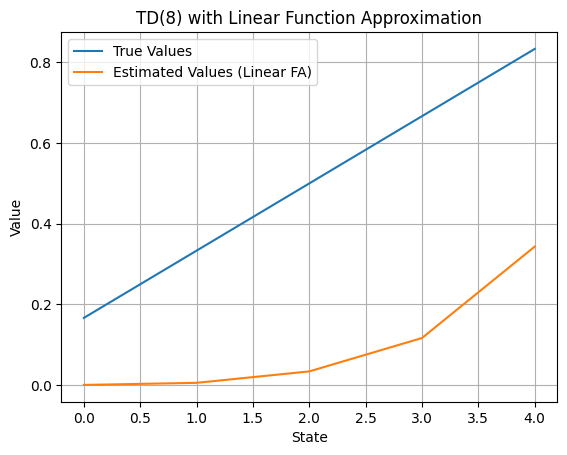

In [14]:
print("Atul Singh, UIN-221A016")
true_values = np.array([1/6, 2/6, 3/6, 4/6, 5/6])

# Initialize weights for linear value function V(s)= w^T x(s)
w = np.zeros(n_states)

# TD(0) with Function Approximation
for ep in range(episodes):
    state = 3 # start at center state (C)
    while True:
        # Determine next state: In a random walk, the agent moves left or right
        # Assuming the states are 1-indexed for the feature function and environment
        # For a 5-state environment (A-E), states could be 1, 2, 3, 4, 5.
        # Terminal states could be 0 and 6.
        next_state = state + np.random.choice([-1, 1])

        # Reward is 1 if we reach the right terminal state (state 6), else 0
        reward = 1.0 if next_state == 6 else 0.0

        # Convert states to features
        X = state_features(state)
        x_next = state_features(next_state)
        # Value predictions
        v = np.dot(w, X)
        v_next = np.dot(w, x_next) if 1 <= next_state <= n_states else 0.0 # V(terminal state) = 0

        # TD(0) update
        td_error = reward + gamma * v_next - v
        w = w + alpha * td_error * X

        if next_state == 0 or next_state == 6:
            break
        state = next_state

# Predict values after training
estimated_values = np.dot(np.eye(n_states), w)

# Plot results
plt.plot(true_values, label='True Values')
plt.plot(estimated_values, label='Estimated Values (Linear FA)')
plt.xlabel('State')
plt.ylabel('Value')
plt.legend()
plt.title('TD(8) with Linear Function Approximation')
plt.grid()

In [12]:
np.eye(5)

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])